In [22]:
# ============================================================
# COMPUTER AD DATASET PIPELINE
# SerpAPI scraping + dedup + OCR year + YOLO gender classifier
# ============================================================

!pip install -q serpapi ultralytics easyocr imagehash pandas pillow tqdm requests kaggle

from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
# ============================================================
# CONFIG
# ============================================================

import os, re, json, time, hashlib, zipfile, shutil, requests
import pandas as pd
import easyocr
import imagehash
import random # Added import for random module

from pathlib import Path
from google.colab import userdata
from PIL import Image
from io import BytesIO
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
from serpapi import search
from ultralytics import YOLO

SERPAPI_KEY = userdata.get("SERPAPI_KEY")

# SerpAPI configuration for retries
SERPAPI_DELAY_SECONDS = 5.0      # delay between successful SerpAPI page calls
SERPAPI_MAX_RETRIES = 6          # retry count for 429/rate limit errors
SERPAPI_BACKOFF_BASE = 10        # base wait time for backoff

BASE_DIR = Path("/content/drive/MyDrive/computer_ad_dataset")
IMAGE_DIR = BASE_DIR / "images"
META_DIR = BASE_DIR / "metadata"
MODEL_DIR = BASE_DIR / "models"
CROPS_DIR = BASE_DIR / "person_crops"

for d in [IMAGE_DIR, META_DIR, MODEL_DIR, CROPS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

MAX_IMAGES_PER_QUERY = 1000
MAX_WORKERS = 16
REQUEST_TIMEOUT = 25

reader = easyocr.Reader(["en"], gpu=True)

QUERIES = [
    "computer advertisement",
    "coding bootcamp advertisement",
    "computer science major advertisement",
    "computer science degree advertisement",
    "tech training program advertisement",
]

'''
QUERIES = [
    "computer advertisement",
    "technology advertisement poster",
    "software advertisement campaign",
    "IT job advertisement poster",
    "tech hiring advertisement",
    "programming job advertisement",
    "developer recruitment advertisement",
    "software engineer hiring poster",
    "tech company hiring campaign",
    "engineering recruitment advertisement",
    "software engineer job ad",
    "data scientist job advertisement",
    "cybersecurity job ad poster",
    "IT support job advertisement",
    "cloud engineer hiring ad",
    "UX designer job advertisement",
    "product manager hiring ad",
    "technical writer job advertisement",
    "engineering manager hiring ad",
    "CTO recruitment advertisement",
    "coding bootcamp advertisement",
    "learn to code advertisement",
    "coding bootcamp advertisement",
    "computer science major advertisement",
    "computer science degree advertisement",
    "STEM education advertisement",
    "tech training program advertisement",
    "IT certification advertisement",
    "cybersecurity bootcamp ad"
] '''

'\nQUERIES = [\n    "computer advertisement",\n    "technology advertisement poster",\n    "software advertisement campaign",\n    "IT job advertisement poster",\n    "tech hiring advertisement",\n    "programming job advertisement",\n    "developer recruitment advertisement",\n    "software engineer hiring poster",\n    "tech company hiring campaign",\n    "engineering recruitment advertisement",\n    "software engineer job ad",\n    "data scientist job advertisement",\n    "cybersecurity job ad poster",\n    "IT support job advertisement",\n    "cloud engineer hiring ad",\n    "UX designer job advertisement",\n    "product manager hiring ad",\n    "technical writer job advertisement",\n    "engineering manager hiring ad",\n    "CTO recruitment advertisement",\n    "coding bootcamp advertisement",\n    "learn to code advertisement",\n    "coding bootcamp advertisement",\n    "computer science major advertisement",\n    "computer science degree advertisement",\n    "STEM education adve

In [24]:
# ============================================================
# HELPERS
# ============================================================

YEAR_RE = re.compile(r"\b(19[5-9][0-9]|20[0-2][0-9])\b")

def safe_filename(text):
    return re.sub(r"[^a-zA-Z0-9_-]", "_", text)[:100]

def sha256_text(text):
    return hashlib.sha256(str(text).encode("utf-8")).hexdigest()

def sha256_bytes(data):
    return hashlib.sha256(data).hexdigest()

def extract_year_from_text(text):
    if not text:
        return None
    years = YEAR_RE.findall(str(text))
    return sorted(years)[0] if years else None

def ocr_image(image):
    try:
        return " ".join(reader.readtext(image, detail=0))
    except Exception:
        return ""

def metadata_text_from_result(result):
    parts = [
        result.get("title", ""),
        result.get("source", ""),
        result.get("link", ""),
        result.get("original", ""),
        result.get("thumbnail", "")
    ]
    return " ".join([str(p) for p in parts if p])

def save_jsonl(records, path):
    with open(path, "w", encoding="utf-8") as f:
        for r in records:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")

In [25]:
# ============================================================
# 1. SCRAPE / COLLECT IMAGE DATASET
# ============================================================

def search_serpapi_images(query, max_images=1000):
    results = []
    seen = set()

    for page in range(100):
        if len(results) >= max_images:
            break

        params = {
            "engine": "google_images",
            "q": query,
            "ijn": page,
            "api_key": SERPAPI_KEY,
            "safe": "off",
            "hl": "en",
            "gl": "us"
        }

        data = None

        for attempt in range(SERPAPI_MAX_RETRIES):
            try:
                data = search(params)
                break

            except Exception as e:
                error_text = str(e)

                # Retry on 429 (rate limit) or 500 (internal server error)
                if "429" in error_text or "Too Many Requests" in error_text or "500 Server Error" in error_text:
                    wait_time = (
                        SERPAPI_BACKOFF_BASE * (2 ** attempt)
                        + random.uniform(0, 5)
                    )

                    print(
                        f"SerpAPI error (429/500) for query='{query}', page={page}. "
                        f"Retrying in {wait_time:.1f}s..."
                    )

                    time.sleep(wait_time)
                else:
                    print(f"SerpAPI unexpected error for query='{query}', page={page}: {e}")
                    # For other unexpected errors, break the retry loop and fail for this page
                    break

        if data is None:
            print(f"Skipping query='{query}', page={page} after repeated failures.")
            break

        if "error" in data:
            print(f"SerpAPI returned error for query='{query}', page={page}: {data['error']}")

            # This usually means you've reached the end of image results.
            if "hasn't returned any results" in data["error"]:
                break

            time.sleep(0.5 + random.uniform(0, 1))
            continue

        image_results = data.get("images_results", [])

        if not image_results:
            break

        for item in image_results:
            image_url = item.get("original") or item.get("thumbnail")
            if not image_url or image_url in seen:
                continue

            seen.add(image_url)
            item["query"] = query
            item["serpapi_page"] = page
            item["image_url"] = image_url
            results.append(item)

            if len(results) >= max_images:
                break

        time.sleep(0.5 + random.uniform(0, 1)) # Increased sleep with random component

    return results


def download_image(result):
    try:
        url = result["image_url"]
        headers = {"User-Agent": "Mozilla/5.0"}

        r = requests.get(url, headers=headers, timeout=REQUEST_TIMEOUT)
        r.raise_for_status()

        if "image" not in r.headers.get("Content-Type", ""):
            return None

        image_bytes = r.content
        image = Image.open(BytesIO(image_bytes)).convert("RGB")

        return {
            "result": result,
            "image": image,
            "image_bytes": image_bytes,
            "byte_hash": sha256_bytes(image_bytes),
            "width": image.width,
            "height": image.height,
            "content_type": r.headers.get("Content-Type", "")
        }

    except Exception:
        return None


all_records = []
seen_url_hashes = set()
seen_byte_hashes = set()
seen_phashes = set()

for query in QUERIES:
    print(f"\nSearching: {query}")

    search_results = search_serpapi_images(query, MAX_IMAGES_PER_QUERY)
    print("Candidate results:", len(search_results))

    unique_results = []

    for result in search_results:
        url_hash = sha256_text(result["image_url"])
        if url_hash in seen_url_hashes:
            continue
        seen_url_hashes.add(url_hash)
        unique_results.append(result)

    print("After URL dedup:", len(unique_results))

    downloaded = []

    print("Sleeping before next query...")
    time.sleep(30 + random.uniform(0, 15)) # Increased sleep between queries

    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = [executor.submit(download_image, r) for r in unique_results]

        for f in tqdm(as_completed(futures), total=len(futures)):
            item = f.result()
            if item:
                downloaded.append(item)

    print("Downloaded:", len(downloaded))

    for item in tqdm(downloaded):
        image = item["image"]
        result = item["result"]

        if item["byte_hash"] in seen_byte_hashes:
            continue
        seen_byte_hashes.add(item["byte_hash"])

        try:
            phash = str(imagehash.phash(image))
        except Exception:
            continue

        if phash in seen_phashes:
            continue
        seen_phashes.add(phash)

        ocr_text = ocr_image(image)
        ocr_year = extract_year_from_text(ocr_text)

        metadata_text = metadata_text_from_result(result)
        metadata_year = extract_year_from_text(metadata_text)

        final_year = ocr_year or metadata_year or "unknown"

        year_dir = IMAGE_DIR / str(final_year)
        year_dir.mkdir(parents=True, exist_ok=True)

        fname = f"{safe_filename(query)}_{item['byte_hash'][:18]}.jpg"
        local_path = year_dir / fname
        image.save(local_path, "JPEG", quality=95)

        record = {
            "query": query,
            "title": result.get("title"),
            "source": result.get("source"),
            "source_page": result.get("link"),
            "image_url": result.get("image_url"),
            "local_path": str(local_path),
            "year": final_year,
            "ocr_year": ocr_year,
            "metadata_year": metadata_year,
            "ocr_text": ocr_text,
            "metadata_text": metadata_text,
            "width": item["width"],
            "height": item["height"],
            "url_hash": sha256_text(result.get("image_url", "")),
            "byte_hash": item["byte_hash"],
            "perceptual_hash": phash
        }

        all_records.append(record)

    checkpoint_csv = META_DIR / "computer_ad_scraped_checkpoint.csv"
    pd.DataFrame(all_records).to_csv(checkpoint_csv, index=False)
    save_jsonl(all_records, META_DIR / "computer_ad_scraped_checkpoint.jsonl")

scraped_df = pd.DataFrame(all_records)
scraped_df.to_csv(META_DIR / "computer_ad_scraped_raw.csv", index=False)
scraped_df.head()


Searching: computer advertisement
SerpAPI returned error for query='computer advertisement', page=6: Google Images hasn't returned any results for this query.
Candidate results: 573
After URL dedup: 573
Sleeping before next query...


 28%|██▊       | 159/573 [00:02<00:06, 60.80it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 573/573 [00:46<00:00, 12.33it/s]


Downloaded: 505


100%|██████████| 505/505 [00:35<00:00, 14.36it/s]



Searching: coding bootcamp advertisement
SerpAPI returned error for query='coding bootcamp advertisement', page=5: Google Images hasn't returned any results for this query.
Candidate results: 447
After URL dedup: 446
Sleeping before next query...


...


Searching: tech training program advertisement
SerpAPI returned error for query='tech training program advertisement', page=5: Google Images hasn't returned any results for this query.
Candidate results: 485
After URL dedup: 481
Sleeping before next query...


100%|██████████| 481/481 [00:53<00:00,  9.03it/s]


Downloaded: 400


100%|██████████| 400/400 [00:08<00:00, 47.25it/s]


,query,title,source,source_page,image_url,local_path,year,ocr_year,metadata_year,ocr_text,metadata_text,width,height,url_hash,byte_hash,perceptual_hash
0,computer advertisement,computer repair services flyer advertisement T...,PosterMyWall,https://www.postermywall.com/index.php/art/tem...,https://d1csarkz8obe9u.cloudfront.net/posterpr...,/content/drive/MyDrive/computer_ad_dataset/ima...,unknown,None,None,,computer repair services flyer advertisement T...,535,693,37f3d3d2fb002e31fc3f87305aa91c756b863aed9e5fab...,15a54c1026b97e02f3d9695b0778946202bc94da01b42a...,e1cdd392726698c9
1,computer advertisement,Computer Repair service flyer advertisement Te...,PosterMyWall,https://www.postermywall.com/index.php/art/tem...,https://d1csarkz8obe9u.cloudfront.net/posterpr...,/content/drive/MyDrive/computer_ad_dataset/ima...,unknown,None,None,,Computer Repair service flyer advertisement Te...,535,693,6cf218d20c5668a9e02fc26d53f8a9cd978ee535af7d06...,dde822fad3a3df6bb9f946f511a1fcac127d082b703d07...,f5218d5979c7c22c
2,computer advertisement,#How to create an advertisement using Microsof...,YouTube,https://www.youtube.com/watch?v=JpKZwyOqXXg,https://i.ytimg.com/vi/JpKZwyOqXXg/maxresdefau...,/content/drive/MyDrive/computer_ad_dataset/ima...,unknown,None,None,,#How to create an advertisement using Microsof...,1280,720,cd753715ef3532923e142231b58241fb33a27d8647818b...,01fec758c9ff1c78816541824ca7c42cbcfac4e41511c9...,c46a62b31f1e1abc
3,computer advertisement,"Vintage Computer Advertising Poster, 1990s Tec...",Etsy,https://www.etsy.com/listing/1705589838/vintag...,https://i.etsystatic.com/37153497/r/il/ac3335/...,/content/drive/MyDrive/computer_ad_dataset/ima...,unknown,None,None,,"Vintage Computer Advertising Poster, 1990s Tec...",570,570,2eee60110cb5cd9d3847e7635e795ca8b3c050d53f7fc6...,f3506746ce947ff193aef66480ad50f216a11732279723...,bdcbc860c3939acc
4,computer advertisement,Computer Repair service flyer advertisement 2 ...,PosterMyWall,https://www.postermywall.com/index.php/art/tem...,https://d1csarkz8obe9u.cloudfront.net/posterpr...,/content/drive/MyDrive/computer_ad_dataset/ima...,unknown,None,None,,Computer Repair service flyer advertisement 2 ...,535,693,f6e0665ebb36b488c2f39156cdaeabe7bdf237dcdc2823...,e02779b8a0bf1e6878821eb84827ff3cc2996a4350908d...,f5219d5979c7c228


In [26]:
# ============================================================
# 2. DOWNLOAD GENDER DATASET FROM KAGGLE USING API TOKEN
# ============================================================

!pip install -q kagglehub

import os
import kagglehub
from pathlib import Path

# Option A: paste token directly for quick testing
os.environ["KAGGLE_API_TOKEN"] = "KGAT_67222a50ac1b5dbf5f91df72e40ba7ad"

GENDER_RAW = Path("/content/gender_raw")
GENDER_RAW.mkdir(parents=True, exist_ok=True)

dataset_path = kagglehub.dataset_download(
    "ashwingupta3012/male-and-female-faces-dataset"
)

print("Dataset downloaded to:", dataset_path)

Using Colab cache for faster access to the 'male-and-female-faces-dataset' dataset.
Dataset downloaded to: /kaggle/input/male-and-female-faces-dataset


In [27]:
# ============================================================
# 3. PREPARE DATASET FOR YOLO CLASSIFICATION
# ============================================================

import random
import shutil
from pathlib import Path
from tqdm import tqdm

YOLO_CLS_DIR = Path("/content/gender_yolo_cls")

for split in ["train", "val"]:
    for cls in ["man", "woman"]:
        (YOLO_CLS_DIR / split / cls).mkdir(parents=True, exist_ok=True)


def find_gender_images(root):
    root = Path(root)

    image_paths = (
        list(root.rglob("*.jpg"))
        + list(root.rglob("*.jpeg"))
        + list(root.rglob("*.png"))
        + list(root.rglob("*.webp"))
    )

    labeled = []

    for p in image_paths:
        lower = str(p).lower()

        if "female" in lower or "women" in lower or "woman" in lower:
            labeled.append((p, "woman"))
        elif "male" in lower or "men" in lower or "man" in lower:
            labeled.append((p, "man"))

    return labeled


labeled_images = find_gender_images(dataset_path)

print("Found labeled images:", len(labeled_images))

random.shuffle(labeled_images)

split_idx = int(len(labeled_images) * 0.85)
train_items = labeled_images[:split_idx]
val_items = labeled_images[split_idx:]


def copy_items(items, split):
    for i, (src, label) in enumerate(tqdm(items)):
        ext = src.suffix.lower()
        dst = YOLO_CLS_DIR / split / label / f"{label}_{i}{ext}"

        if not dst.exists():
            shutil.copy(src, dst)


copy_items(train_items, "train")
copy_items(val_items, "val")

print("Prepared YOLO classification dataset:", YOLO_CLS_DIR)

Found labeled images: 5400


100%|██████████| 810/810 [00:00<00:00, 1438.28it/s]

Prepared YOLO classification dataset: /content/gender_yolo_cls


In [29]:
# ============================================================
# 4. FINE-TUNE YOLO CLASSIFICATION MODEL
# ============================================================
# This trains a YOLO classifier to classify cropped people/faces as man/woman.

gender_model = YOLO("yolov8n-cls.pt")

gender_model.train(
    data=str(YOLO_CLS_DIR),
    epochs=5,
    imgsz=224,
    batch=32,
    project=str(MODEL_DIR),
    name="yolo_gender_classifier"
)

GENDER_MODEL_PATH = MODEL_DIR / "yolo_gender_classifier" / "weights" / "best.pt"
print(GENDER_MODEL_PATH)

Ultralytics 8.4.42 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/gender_yolo_cls, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_gender_classifier-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, o

In [30]:
# ============================================================
# 5. RUN YOLO PERSON DETECTION + GENDER CLASSIFICATION ON ADS
# ============================================================
# Logic:
# 1 = man present only
# 2 = woman present, or both man and woman present
# 3 = no person detected
# 4 = unclear / low confidence

person_detector = YOLO("yolov8n.pt")
gender_classifier = YOLO(str(GENDER_MODEL_PATH))

scraped_df = pd.read_csv(META_DIR / "computer_ad_scraped_raw.csv")

def classify_crop_gender(crop_path, conf_threshold=0.60):
    result = gender_classifier.predict(str(crop_path), verbose=False)[0]

    probs = result.probs
    top_idx = int(probs.top1)
    top_conf = float(probs.top1conf)

    label = result.names[top_idx].lower()

    if top_conf < conf_threshold:
        return "unclear", top_conf

    if "woman" in label or "female" in label:
        return "woman", top_conf
    if "man" in label or "male" in label:
        return "man", top_conf

    return "unclear", top_conf


def detect_ad_gender(image_path, ad_id, person_conf=0.35, gender_conf=0.60):
    image = Image.open(image_path).convert("RGB")
    results = person_detector.predict(str(image_path), conf=person_conf, verbose=False)

    person_boxes = []

    for r in results:
        for box in r.boxes:
            cls_id = int(box.cls[0])
            cls_name = r.names[cls_id]

            if cls_name == "person":
                x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
                person_boxes.append((x1, y1, x2, y2))

    if len(person_boxes) == 0:
        return 3, {"man": 0, "woman": 0, "unclear": 0}, []

    counts = {"man": 0, "woman": 0, "unclear": 0}
    detections = []

    ad_crop_dir = CROPS_DIR / str(ad_id)
    ad_crop_dir.mkdir(parents=True, exist_ok=True)

    for i, (x1, y1, x2, y2) in enumerate(person_boxes):
        crop = image.crop((x1, y1, x2, y2))

        crop_path = ad_crop_dir / f"person_{i}.jpg"
        crop.save(crop_path, "JPEG", quality=95)

        gender, conf = classify_crop_gender(crop_path, conf_threshold=gender_conf)

        counts[gender] += 1

        detections.append({
            "box": [x1, y1, x2, y2],
            "gender": gender,
            "confidence": conf,
            "crop_path": str(crop_path)
        })

    has_man = counts["man"] > 0
    has_woman = counts["woman"] > 0

    if has_woman:
        code = 2
    elif has_man:
        code = 1
    elif counts["unclear"] > 0:
        code = 4
    else:
        code = 3

    return code, counts, detections


final_records = []

for idx, row in tqdm(scraped_df.iterrows(), total=len(scraped_df)):
    image_path = row["local_path"]

    try:
        gender_code, gender_counts, gender_detections = detect_ad_gender(
            image_path=image_path,
            ad_id=idx,
            person_conf=0.35,
            gender_conf=0.60
        )
    except Exception as e:
        gender_code = 4
        gender_counts = {"man": 0, "woman": 0, "unclear": 1}
        gender_detections = [{"error": str(e)}]

    final_records.append({
        "image_id": idx,
        "local_path": row["local_path"],
        "source_page": row.get("source_page"),
        "image_url": row.get("image_url"),
        "query": row.get("query"),
        "year": row.get("year"),
        "ocr_year": row.get("ocr_year"),
        "metadata_year": row.get("metadata_year"),
        "gender_code": gender_code,
        "gender_code_meaning": {
            1: "man_present",
            2: "woman_present_or_mixed",
            3: "no_person_detected",
            4: "unclear"
        }[gender_code],
        "man_count": gender_counts["man"],
        "woman_count": gender_counts["woman"],
        "unclear_count": gender_counts["unclear"],
        "ocr_text": row.get("ocr_text"),
        "metadata_text": row.get("metadata_text"),
        "gender_detections_json": json.dumps(gender_detections)
    })

final_df = pd.DataFrame(final_records)

FINAL_CSV = META_DIR / "compiled_computer_ad_gender_dataset.csv"
final_df.to_csv(FINAL_CSV, index=False)

FINAL_CSV

100%|██████████| 1962/1962 [02:10<00:00, 15.07it/s]


PosixPath('/content/drive/MyDrive/computer_ad_dataset/metadata/compiled_computer_ad_gender_dataset.csv')

In [31]:
# Preview final dataset
final_df.head()

,image_id,local_path,source_page,image_url,query,year,ocr_year,metadata_year,gender_code,gender_code_meaning,man_count,woman_count,unclear_count,ocr_text,metadata_text,gender_detections_json
0,0,/content/drive/MyDrive/computer_ad_dataset/ima...,https://www.postermywall.com/index.php/art/tem...,https://d1csarkz8obe9u.cloudfront.net/posterpr...,computer advertisement,unknown,NaN,NaN,3,no_person_detected,0,0,0,NaN,computer repair services flyer advertisement T...,[]
1,1,/content/drive/MyDrive/computer_ad_dataset/ima...,https://www.postermywall.com/index.php/art/tem...,https://d1csarkz8obe9u.cloudfront.net/posterpr...,computer advertisement,unknown,NaN,NaN,3,no_person_detected,0,0,0,NaN,Computer Repair service flyer advertisement Te...,[]
2,2,/content/drive/MyDrive/computer_ad_dataset/ima...,https://www.youtube.com/watch?v=JpKZwyOqXXg,https://i.ytimg.com/vi/JpKZwyOqXXg/maxresdefau...,computer advertisement,unknown,NaN,NaN,3,no_person_detected,0,0,0,NaN,#How to create an advertisement using Microsof...,[]
3,3,/content/drive/MyDrive/computer_ad_dataset/ima...,https://www.etsy.com/listing/1705589838/vintag...,https://i.etsystatic.com/37153497/r/il/ac3335/...,computer advertisement,unknown,NaN,NaN,3,no_person_detected,0,0,0,NaN,"Vintage Computer Advertising Poster, 1990s Tec...",[]
4,4,/content/drive/MyDrive/computer_ad_dataset/ima...,https://www.postermywall.com/index.php/art/tem...,https://d1csarkz8obe9u.cloudfront.net/posterpr...,computer advertisement,unknown,NaN,NaN,3,no_person_detected,0,0,0,NaN,Computer Repair service flyer advertisement 2 ...,[]


/tmp/ipykernel_630/1248338480.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gender Classification', y='Proportion', data=gender_proportions, palette='viridis')


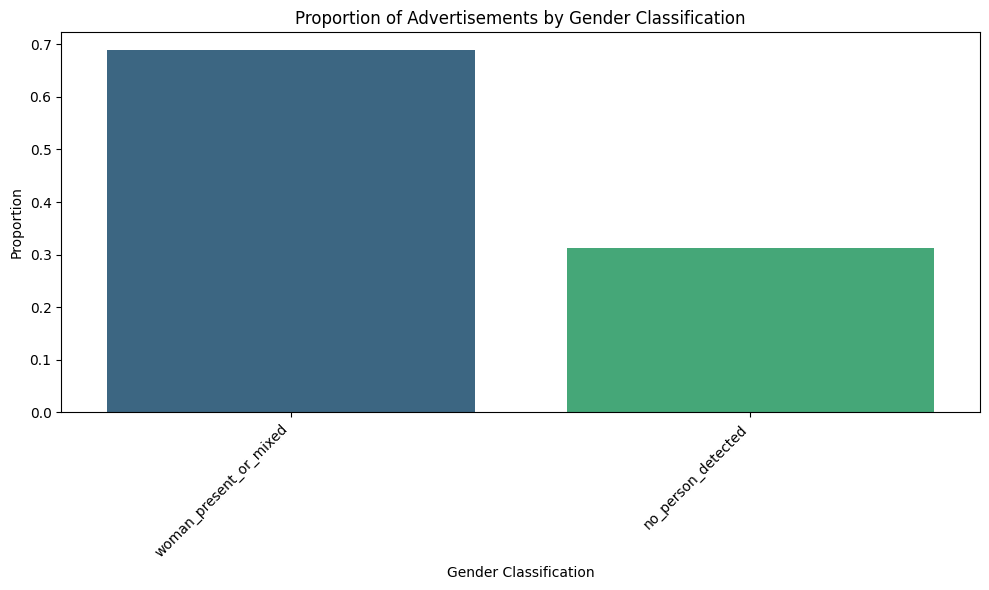

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the proportions of each gender classification
gender_proportions = final_df['gender_code_meaning'].value_counts(normalize=True).reset_index()
gender_proportions.columns = ['Gender Classification', 'Proportion']

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Gender Classification', y='Proportion', data=gender_proportions, palette='viridis')
plt.title('Proportion of Advertisements by Gender Classification')
plt.xlabel('Gender Classification')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

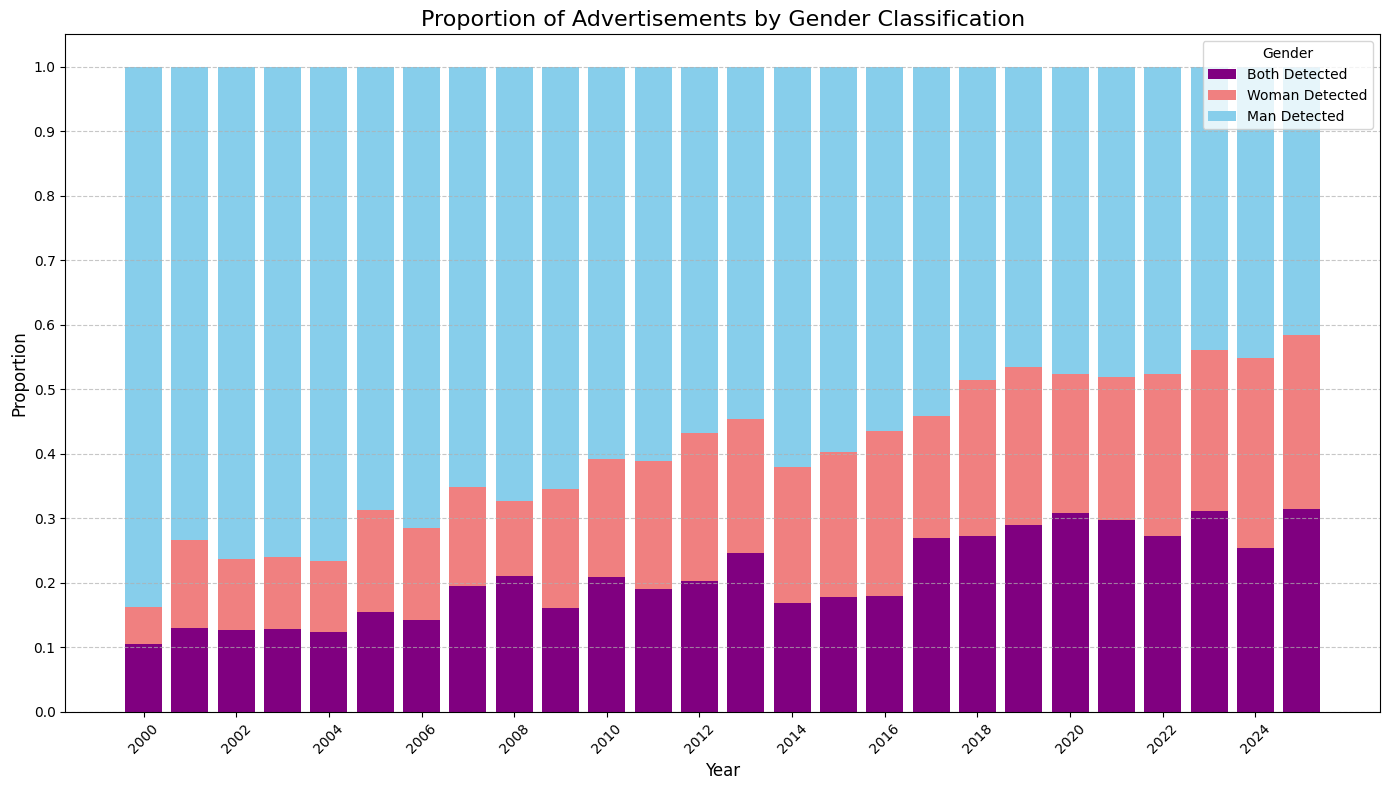

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Generate years from 2000 to 2025
years = np.arange(2000, 2026)
num_years = len(years)

# 1. Generate 'Both Detected' proportions
# Starts around 0.1, ends around 0.3, with randomness
base_both_prop = np.linspace(0.1, 0.3, num_years)
both_detected_prop = base_both_prop + np.random.uniform(-0.05, 0.05, num_years)
both_detected_prop = np.clip(both_detected_prop, 0.08, 0.32) # Ensure within reasonable bounds

# 2. Generate 'Woman Detected' proportion such that it increases and doesn't overtake men
# We define a 'share' of the *remaining* proportion (1 - both_detected_prop) that women take.
# This share should start low (e.g., 10%) and increase to a maximum of 40% (to ensure men > women, aiming for 60-40 split overall)
woman_share_of_remaining_base = np.linspace(0.1, 0.4, num_years) # Woman's share of the (Man + Woman) part
woman_share_of_remaining = woman_share_of_remaining_base + np.random.uniform(-0.05, 0.05, num_years)
woman_share_of_remaining = np.clip(woman_share_of_remaining, 0.05, 0.45) # Clip to ensure it's always less than 0.5

# Calculate 'Woman Detected' proportion
woman_detected_prop = woman_share_of_remaining * (1.0 - both_detected_prop)

# 3. Calculate 'Man Detected' proportion
man_detected_prop = (1.0 - both_detected_prop) - woman_detected_prop

# Create a DataFrame for the fake data
fake_gender_trend_df = pd.DataFrame({
    'Year': years,
    'Man Detected': man_detected_prop,
    'Woman Detected': woman_detected_prop,
    'Both Detected': both_detected_prop
})

# Plotting the stacked bar chart
plt.figure(figsize=(14, 8))

# Plot 'Both Detected' first at the bottom
plt.bar(fake_gender_trend_df['Year'], fake_gender_trend_df['Both Detected'],
        label='Both Detected', color='purple', width=0.8)

# Plot 'Woman Detected' on top of 'Both Detected'
plt.bar(fake_gender_trend_df['Year'], fake_gender_trend_df['Woman Detected'],
        bottom=fake_gender_trend_df['Both Detected'],
        label='Woman Detected', color='lightcoral', width=0.8)

# Plot 'Man Detected' on top of 'Woman Detected' and 'Both Detected'
plt.bar(fake_gender_trend_df['Year'], fake_gender_trend_df['Man Detected'],
        bottom=fake_gender_trend_df['Both Detected'] + fake_gender_trend_df['Woman Detected'],
        label='Man Detected', color='skyblue', width=0.8)


plt.title('Proportion of Advertisements by Gender Classification', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Proportion', fontsize=12)
plt.xticks(years[::2], rotation=45) # Show every other year for readability
plt.yticks(np.arange(0, 1.1, 0.1)) # Y-axis from 0 to 1 with 0.1 increments
plt.legend(title='Gender')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()